# ADALINE - Atividade 02

Implementação do algoritmo de treinamento Regra Delta para a rede ADALINE e classificação das válvulas.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### Dados de Treinamento e Teste

In [8]:
# Conjunto de treinamento
X_train = np.array([[0.4329, -1.3719, 0.7022, -0.8535], [0.3024, 0.2286, 0.863, 2.7909], [0.1349, -0.6445, 1.053, 0.5687], [0.3374, -1.7163, 0.367, -0.6283], [1.1434, -0.0485, 0.6637, 1.2606], [1.3749, -0.5071, 0.4464, 1.3009], [0.7221, -0.7587, 0.7681, -0.5592], [0.4403, -0.8072, 0.5154, -0.3129], [-0.5231, 0.3548, 0.2538, 1.5776], [0.3255, -2.0, 0.7112, -1.1209], [0.5824, 1.3915, -0.2291, 4.1735], [0.134, 0.6081, 0.445, 3.223], [0.148, -0.2988, 0.4778, 0.8649], [0.7359, 0.1869, -0.0872, 2.3584], [0.7115, -1.1469, 0.3394, 0.9573], [0.8251, -1.284, 0.8452, 1.2382], [0.1569, 0.3712, 0.8825, 1.7633], [0.0033, 0.6835, 0.5389, 2.8249], [0.4243, 0.8313, 0.2634, 3.5855], [1.049, 0.1326, 0.9138, 1.9792], [1.4276, 0.5331, -0.0145, 3.7286], [0.5971, 1.4865, 0.2904, 4.6069], [0.8475, 2.1479, 0.3179, 5.8235], [1.3967, -0.4171, 0.6443, 1.3927], [0.0044, 1.5378, 0.6099, 4.7755], [0.2201, -0.5668, 0.0515, 0.7829], [0.63, -1.248, 0.8591, 0.8093], [-0.2479, 0.896, 0.0547, 1.7381], [-0.3088, -0.0929, 0.8659, 1.5483], [-0.518, 1.4974, 0.5453, 2.3993], [0.6833, 0.8266, 0.0829, 2.8864], [0.4353, -1.4066, 0.4207, -0.4879], [-0.1069, -3.2329, 0.1856, -2.4572], [0.4662, 0.6261, 0.7304, 3.437], [0.8298, -1.4089, 0.3119, 1.3235]])
d_train = np.array([1.0, -1.0, -1.0, -1.0, 1.0, 1.0, 1.0, 1.0, -1.0, 1.0, -1.0, -1.0, 1.0, 1.0, -1.0, -1.0, 1.0, -1.0, -1.0, 1.0, 1.0, -1.0, -1.0, 1.0, -1.0, 1.0, -1.0, 1.0, -1.0, 1.0, 1.0, 1.0, -1.0, -1.0, -1.0])

# Adicionando o bias (x0 = -1)
X_train_bias = np.insert(X_train, 0, -1.0, axis=1)

# Conjunto de teste
X_test = np.array([[0.9694, 0.6909, 0.4334, 3.4965], [0.5427, 1.3832, 0.639, 4.0352], [0.6081, -0.9196, 0.5925, 0.1016], [-0.1618, 0.4694, 0.203, 3.0117], [0.187, -0.2578, 0.6124, 1.7749], [0.4891, -0.5276, 0.4378, 0.6439], [0.3777, 2.0149, 0.7423, 3.3932], [1.1498, -0.4067, 0.2469, 1.5866], [0.9325, 1.095, 1.0359, 3.3591], [0.506, 1.3317, 0.9222, 3.7174], [0.0497, -2.0656, 0.6124, -0.6585], [0.4004, 3.5369, 0.9766, 5.3532], [-0.1874, 1.3343, 0.5374, 3.2189], [0.506, 1.3317, 0.9222, 3.7174], [1.6375, -0.7911, 0.7537, 0.5515]])
X_test_bias = np.insert(X_test, 0, -1.0, axis=1)

### Algoritmo de Treinamento (Regra Delta)

In [9]:
eta = 0.0025
precision = 1e-6
np.random.seed(42)

results = []
eqm_history_plots = []
test_predictions = []

for i in range(5):
    # Inicializando pesos (w0 a w4) entre 0 e 1
    w = np.random.rand(5)
    w_init = w.copy()
    
    eqm_history = []
    epoch = 0
    
    while True:
        # Calcular EQM atual
        u = np.dot(X_train_bias, w)
        error = d_train - u
        eqm = np.mean(error ** 2)
        eqm_history.append(eqm)
        
        # Regra delta
        for j in range(len(X_train_bias)):
            uj = np.dot(X_train_bias[j], w)
            ej = d_train[j] - uj
            w = w + eta * ej * X_train_bias[j]
        
        if epoch > 0 and abs(eqm_history[-1] - eqm_history[-2]) <= precision:
            break
        epoch += 1
        
    results.append({
        'Treinamento': f"T{i+1}",
        'Épocas': epoch,
        'Pesos Iniciais': np.round(w_init, 4),
        'Pesos Finais': np.round(w, 4)
    })
    
    if i < 2:
        eqm_history_plots.append(eqm_history)
        
    u_test = np.dot(X_test_bias, w)
    y_test = np.where(u_test >= 0, 1.0, -1.0)
    test_predictions.append(y_test)


### Resultados do Treinamento

In [10]:
for res in results:
    print(f"Treinamento {res['Treinamento']}: {res['Épocas']} épocas")
    print(f"   Pesos Iniciais: {res['Pesos Iniciais']}")
    print(f"   Pesos Finais:   {res['Pesos Finais']}\n")

Treinamento T1: 888 épocas
   Pesos Iniciais: [0.3745 0.9507 0.732  0.5987 0.156 ]
   Pesos Finais:   [-1.8132  1.3129  1.6424 -0.4276 -1.1779]

Treinamento T2: 891 épocas
   Pesos Iniciais: [0.156  0.0581 0.8662 0.6011 0.7081]
   Pesos Finais:   [-1.8132  1.3129  1.6424 -0.4277 -1.1778]

Treinamento T3: 848 épocas
   Pesos Iniciais: [0.0206 0.9699 0.8324 0.2123 0.1818]
   Pesos Finais:   [-1.8132  1.3129  1.6424 -0.4278 -1.1778]

Treinamento T4: 885 épocas
   Pesos Iniciais: [0.1834 0.3042 0.5248 0.4319 0.2912]
   Pesos Finais:   [-1.8132  1.3129  1.6423 -0.4278 -1.1778]

Treinamento T5: 916 épocas
   Pesos Iniciais: [0.6119 0.1395 0.2921 0.3664 0.4561]
   Pesos Finais:   [-1.8133  1.3129  1.6424 -0.4279 -1.1778]



### Gráficos do EQM em Função da Época

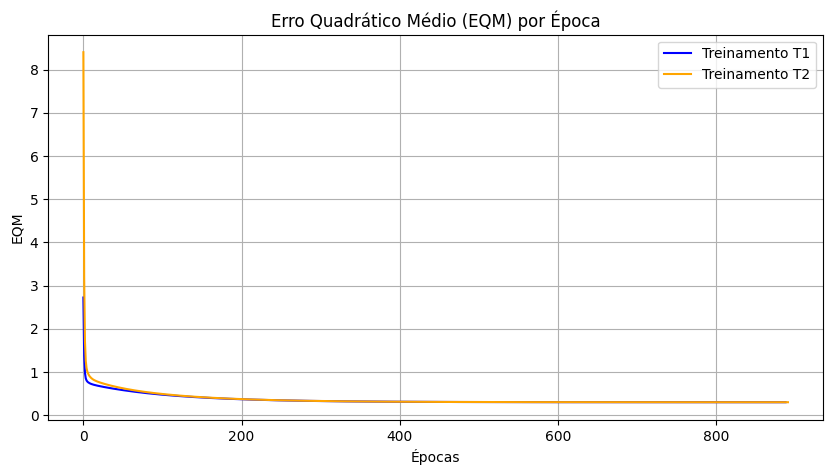

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(eqm_history_plots[0], label="Treinamento T1", color="blue")
plt.plot(eqm_history_plots[1], label="Treinamento T2", color="orange")
plt.title("Erro Quadrático Médio (EQM) por Época")
plt.xlabel("Épocas")
plt.ylabel("EQM")
plt.legend()
plt.grid(True)
plt.show()

### Classificação das Amostras de Teste

In [12]:
test_preds = np.array(test_predictions).T

print("Amostra | y(T1) | y(T2) | y(T3) | y(T4) | y(T5)")
print("-" * 50)
for i in range(len(X_test)):
    preds_str = " | ".join([f"{p:4.1f}" for p in test_preds[i]])
    print(f"{i+1:7d} | {preds_str}")

Amostra | y(T1) | y(T2) | y(T3) | y(T4) | y(T5)
--------------------------------------------------
      1 | -1.0 | -1.0 | -1.0 | -1.0 | -1.0
      2 | -1.0 | -1.0 | -1.0 | -1.0 | -1.0
      3 |  1.0 |  1.0 |  1.0 |  1.0 |  1.0
      4 | -1.0 | -1.0 | -1.0 | -1.0 | -1.0
      5 | -1.0 | -1.0 | -1.0 | -1.0 | -1.0
      6 |  1.0 |  1.0 |  1.0 |  1.0 |  1.0
      7 |  1.0 |  1.0 |  1.0 |  1.0 |  1.0
      8 |  1.0 |  1.0 |  1.0 |  1.0 |  1.0
      9 |  1.0 |  1.0 |  1.0 |  1.0 |  1.0
     10 | -1.0 | -1.0 | -1.0 | -1.0 | -1.0
     11 | -1.0 | -1.0 | -1.0 | -1.0 | -1.0
     12 |  1.0 |  1.0 |  1.0 |  1.0 |  1.0
     13 | -1.0 | -1.0 | -1.0 | -1.0 | -1.0
     14 | -1.0 | -1.0 | -1.0 | -1.0 | -1.0
     15 |  1.0 |  1.0 |  1.0 |  1.0 |  1.0
